In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time
# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)
# CIFAR-10 Class Names
CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
'dog','frog','horse','ship','truck']
# Load Data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()
# Fixed Split: 40,000 train / 10,000 val / 10,000 test
x_train = x_train_full[:40000].astype('float32')
y_train = y_train_full[:40000]
x_val = x_train_full[40000:].astype('float32')
y_val = y_train_full[40000:]
x_test = x_test.astype('float32')
print(f"Train: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}")
print(f"Pixel range: [{x_train.min()}, {x_train.max()}]")
print(f"Image shape: {x_train[0].shape}")

Train: (40000, 32, 32, 3) | Val: (10000, 32, 32, 3) | Test: (10000, 32, 32, 3)
Pixel range: [0.0, 255.0]
Image shape: (32, 32, 3)


In [2]:
def train_and_evaluate(model, x_tr, y_tr, x_v, y_v, x_te, y_te,
epochs=20, batch_size=128, extra_callbacks=None):

    cb = extra_callbacks if extra_callbacks else []
    start = time.time()
    history = model.fit(x_tr, to_categorical(y_tr, 10),
    validation_data=(x_v, to_categorical(y_v, 10)),
    epochs=epochs, batch_size=batch_size,
    callbacks=cb, verbose=0)

    elapsed = time.time() - start
    test_loss, test_acc = model.evaluate(x_te, to_categorical(y_te, 10), verbose=0)
    print(f"Test Acc: {test_acc:.4f} | Test Loss: {test_loss:.4f} | Time: {elapsed:.1f}s")
    return history, test_acc, test_loss, elapsed

In [3]:
def plot_curves(histories, labels, metric='val_accuracy', title='', ylabel=''):
    plt.figure(figsize=(10, 6))
    for h, lbl in zip(histories, labels):
        plt.plot(h.history[metric], label=lbl)
    plt.xlabel('Epoch')
    plt.ylabel(ylabel if ylabel else metric)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

## 2A

In [4]:
# standardize data
mean = np.mean(x_train, axis=(0, 1, 2))
std = np.std(x_train, axis=(0, 1, 2))
x_train_std = (x_train - mean) / std
x_val_std = (x_val - mean) / std
x_test_std = (x_test - mean) / std


print(np.mean(x_train_std))
print(np.std(x_train_std))

4.0611885e-06
1.0000004


In [5]:
def build_cnn_model(f1,f2,f3,f4):
    
    model = models.Sequential([
        # layer 1 
        layers.Conv2D(f1, (3,3), activation='relu',padding='same', input_shape=(32, 32, 3)),
        
        # layer 2
        layers.Conv2D(f2,(3,3), activation='relu', padding='same'),
        
        layers.MaxPooling2D((2, 2)),
        
        # layer 3
        layers.Conv2D(f3,(3,3), activation='relu', padding='same'),
        
        # layer 4
        layers.Conv2D(f4,(3,3), activation='relu', padding='same'),
        
        layers.MaxPooling2D((2, 2)),
        
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
        
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']    
        
    )
    return model



models_config = {
    "Small": (8, 8, 16, 16),
    "Medium": (32, 32, 64, 64),
    "Large": (64, 64, 128, 128)
}

histories = []
labels = []
results = []

for name, (f1, f2, f3, f4) in models_config.items():
    
    print(f"\nTraining {name} model...")
    
    model = build_cnn_model(f1, f2, f3, f4)
    
    model.summary() 
    
    history, test_acc, test_loss, t = train_and_evaluate(
        model,
        x_train_std, y_train,
        x_val_std, y_val,
        x_test_std, y_test
    )
    
    histories.append(history)
    labels.append(name)
    
    results.append({
        "Model": name,
        "Test Acc": test_acc,
        "Test Loss": test_loss,
        "Time": t
    })



Training Small model...


c:\Users\zeyad\anaconda3\envs\ml\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 136,786 (534.32 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,310,154 (5.00 MB)

 Trainable params: 1,310,154 (5.00 MB)

 Non-trainable params: 0 (0.00 B)

Test Acc: 0.7379 | Test Loss: 1.9623 | Time: 1328.4s


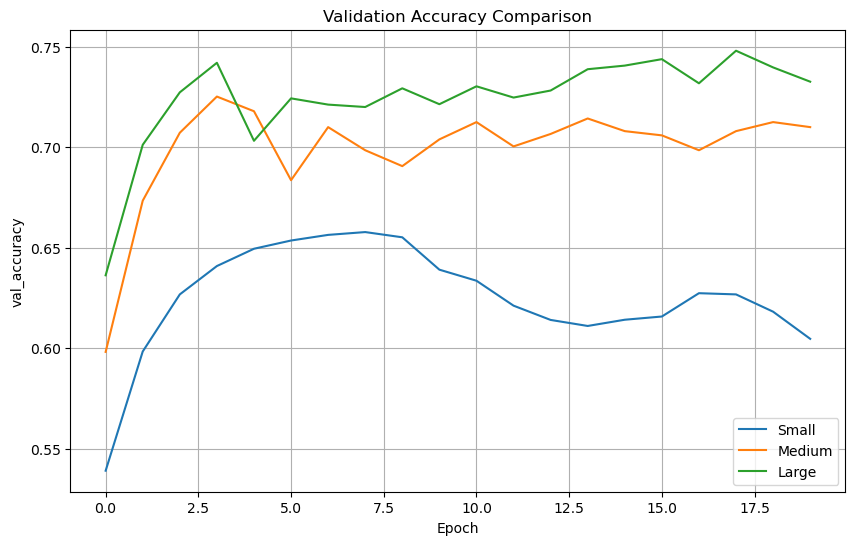

In [6]:
plot_curves(
    histories,
    labels,
    metric='val_accuracy',
    title='Validation Accuracy Comparison'
)

## 2C

In [7]:
def build_shallow():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    
    model.compile(optimizer=keras.optimizers.Adam(0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    
    return model

def build_medium_depth():
    model = models.Sequential([
        
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        
        layers.GlobalAveragePooling2D(),
        
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    
    model.compile(optimizer=keras.optimizers.Adam(0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    
    return model

def build_deep():
    model = models.Sequential([
        
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        
        layers.GlobalAveragePooling2D(),
        
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    
    model.compile(optimizer=keras.optimizers.Adam(0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    
    return model

In [8]:
models_dict = {
    "Shallow": build_shallow(),
    "Medium": build_medium_depth(),
    "Deep": build_deep()
}

histories = {}
results = []

for name, model in models_dict.items():
    
    print(f"\nTraining {name} model...")
    
    model.summary()
    
    history, test_acc, test_loss, t = train_and_evaluate(
        model,
        x_train_std, y_train,
        x_val_std, y_val,
        x_test_std, y_test
    )
    
    histories[name] = history
    
    results.append({
        "Model": name,
        "Test Acc": test_acc,
        "Test Loss": test_loss,
        "Time": t
    })


Training Shallow model...


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 555,754 (2.12 MB)

 Trainable params: 555,754 (2.12 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 4, 4, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 4, 4, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │         8,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,650 (299.41 KB)

 Trainable params: 76,650 (299.41 KB)

 Non-trainable params: 0 (0.00 B)

Test Acc: 0.7336 | Test Loss: 0.8432 | Time: 325.1s


In [9]:
import pandas as pd

In [10]:
df = pd.DataFrame(results)
print(df)

     Model  Test Acc  Test Loss        Time
0  Shallow    0.6764   2.558374  320.233764
1   Medium    0.7304   0.791614  324.830038
2     Deep    0.7336   0.843173  325.058717


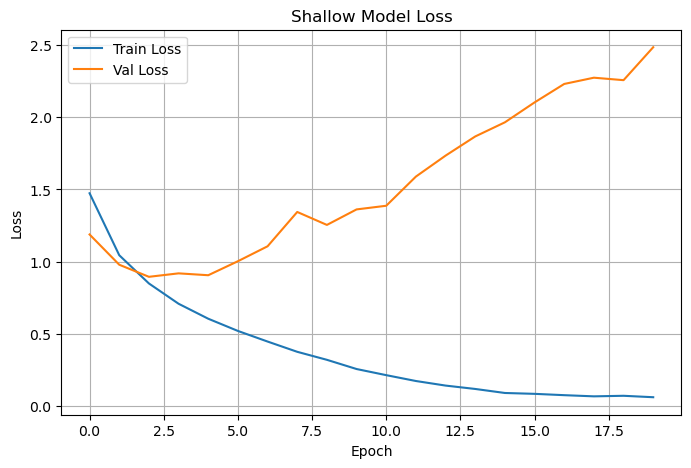

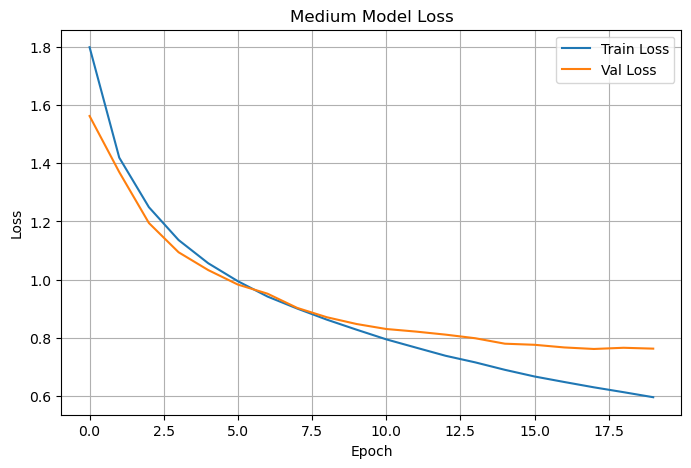

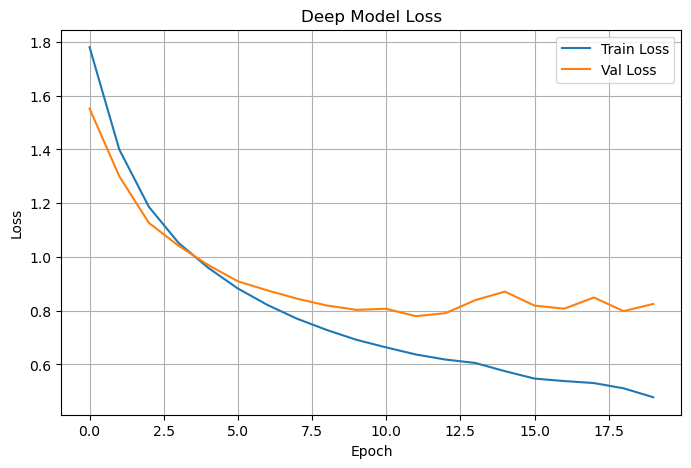

In [11]:
for name, history in histories.items():
    
    plt.figure(figsize=(8,5))
    
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    
    plt.title(f'{name} Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.show()

## 4A

In [12]:
optimizers = {
    'SGD': keras.optimizers.SGD(learning_rate=0.001),
    'Momentum': keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
    'AdaGrad': keras.optimizers.Adagrad(learning_rate=0.001),
    'RMSProp': keras.optimizers.RMSprop(learning_rate=0.001),
    'Adam': keras.optimizers.Adam(learning_rate=0.001),
}

def build_medium_model():
    return build_cnn_model(32, 32, 64, 64)

histories = []
labels = []
results = []

for name, opt in optimizers.items():
    
    print(f"\nTraining with {name} optimizer...")
    
    model = build_medium_model()
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    
    history, test_acc, test_loss, t = train_and_evaluate(
        model,
        x_train_std, y_train,
        x_val_std, y_val,
        x_test_std, y_test
    )
    
    histories.append(history)
    labels.append(name)
    
    results.append({
        "Optimizer": name,
        "Test Acc": test_acc,
        "Test Loss": test_loss,
        "Time": t
    })




Training with SGD optimizer...


c:\Users\zeyad\anaconda3\envs\ml\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Acc: 0.4817 | Test Loss: 1.4658 | Time: 408.0s

Training with Momentum optimizer...
Test Acc: 0.6810 | Test Loss: 0.9549 | Time: 328.4s

Training with AdaGrad optimizer...
Test Acc: 0.5443 | Test Loss: 1.2862 | Time: 333.5s

Training with RMSProp optimizer...
Test Acc: 0.7170 | Test Loss: 2.4220 | Time: 346.7s

Training with Adam optimizer...
Test Acc: 0.7121 | Test Loss: 2.0794 | Time: 352.5s


In [14]:
df = pd.DataFrame(results)
print(df)

  Optimizer  Test Acc  Test Loss        Time
0       SGD    0.4817   1.465785  407.975395
1  Momentum    0.6810   0.954851  328.385936
2   AdaGrad    0.5443   1.286244  333.478745
3   RMSProp    0.7170   2.421973  346.677209
4      Adam    0.7121   2.079444  352.458878


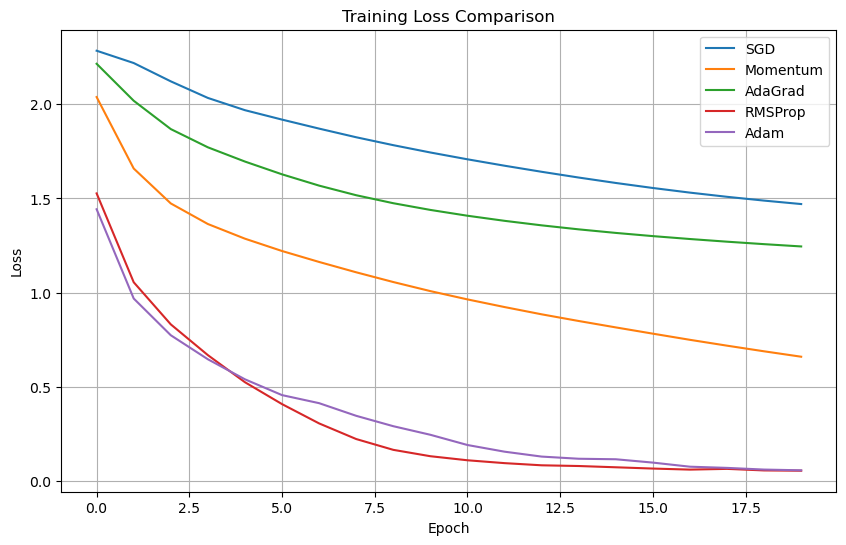

In [15]:
plot_curves(
    histories,
    labels,
    metric='loss',
    title='Training Loss Comparison',
    ylabel='Loss'
)

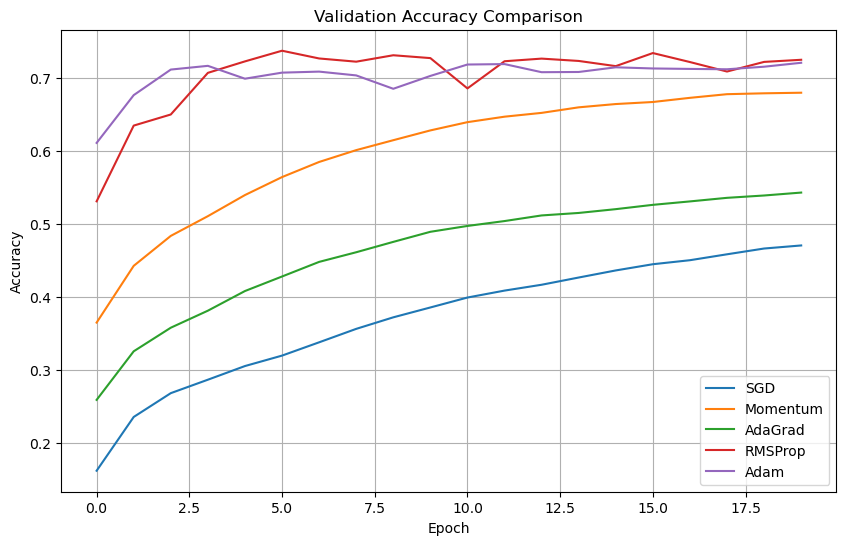

In [16]:
plot_curves(
    histories,
    labels,
    metric='val_accuracy',
    title='Validation Accuracy Comparison',
    ylabel='Accuracy'
)

## 4B

In [17]:
learning_rates = {
    '0.0001': 0.0001,
    '0.001': 0.001,
    '0.01': 0.01
}
histories = []
labels = []
results = []

for name, lr in learning_rates.items():
    
    print(f"\nTraining with learning rate = {lr}")
    
    model = build_medium_model()
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    history, test_acc, test_loss, t = train_and_evaluate(
        model,
        x_train_std, y_train,
        x_val_std, y_val,
        x_test_std, y_test,
        epochs=30
    )
    
    histories.append(history)
    labels.append(name)
    
    results.append({
        "Learning Rate": lr,
        "Train Loss": history.history['loss'][-1],
        "Val Loss": history.history['val_loss'][-1],
        "Test Acc": test_acc
    })


Training with learning rate = 0.0001


c:\Users\zeyad\anaconda3\envs\ml\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Acc: 0.6737 | Test Loss: 1.1400 | Time: 485.6s

Training with learning rate = 0.001
Test Acc: 0.7032 | Test Loss: 2.7158 | Time: 498.0s

Training with learning rate = 0.01
Test Acc: 0.4656 | Test Loss: 2.2818 | Time: 582.1s


In [18]:
df = pd.DataFrame(results)
print(df)

   Learning Rate  Train Loss  Val Loss  Test Acc
0         0.0001    0.394763  1.117356    0.6737
1         0.0010    0.044489  2.620794    0.7032
2         0.0100    0.883257  2.243878    0.4656


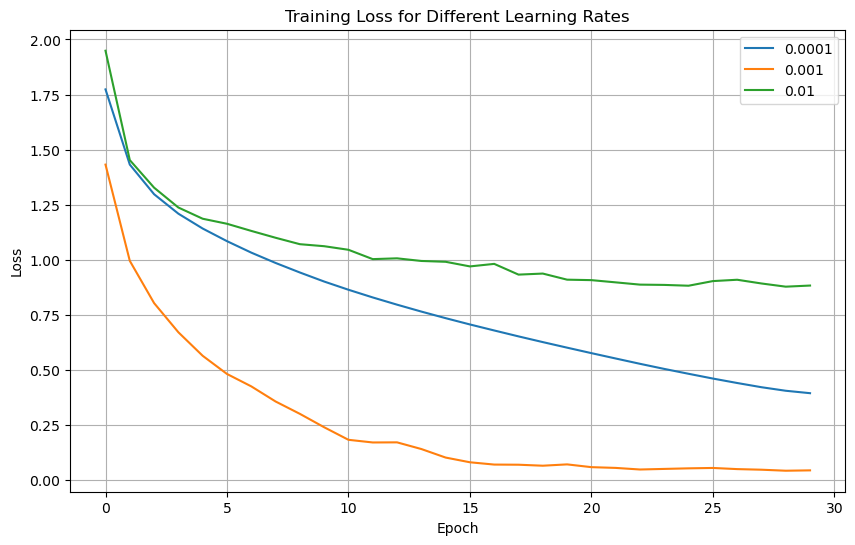

In [19]:
plot_curves(
    histories,
    labels,
    metric='loss',
    title='Training Loss for Different Learning Rates',
    ylabel='Loss'
)

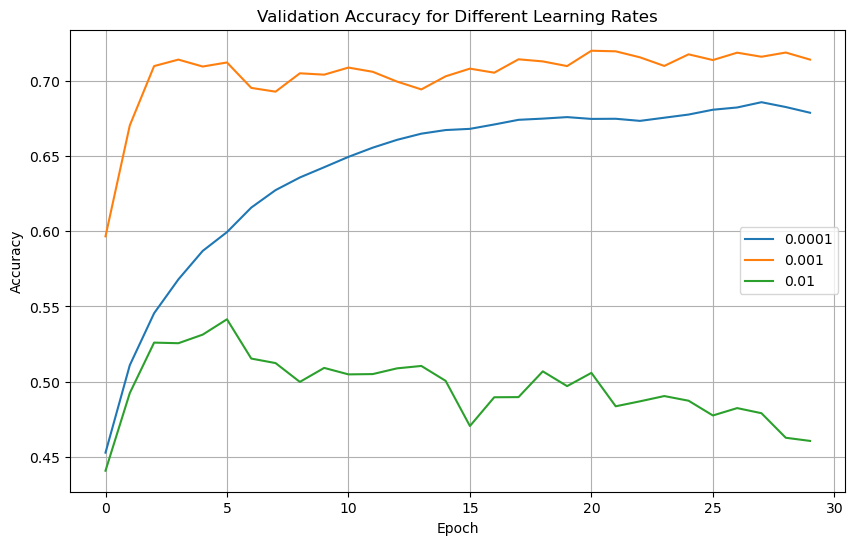

In [20]:
plot_curves(
    histories,
    labels,
    metric='val_accuracy',
    title='Validation Accuracy for Different Learning Rates',
    ylabel='Accuracy'
)

### 6A

### building the medium model (scratch model)

In [ ]:
x_train_resized = tf.image.resize(x_train_std, (48, 48)).numpy()
x_val_resized = tf.image.resize(x_val_std, (48, 48)).numpy()
x_test_resized = tf.image.resize(x_test_std, (48, 48)).numpy()
histories = []
test_accs = []
test_losses = []
times = []
models = []
f1,f2,f3,f4 = models_config["Medium"]
x_train_resized = tf.image.resize(x_train_std, (48, 48)).numpy()
x_val_resized = tf.image.resize(x_val_std, (48, 48)).numpy()
x_test_resized = tf.image.resize(x_test_std, (48, 48)).numpy()
histories = []
test_accs = []
test_losses = []
times = []
model_list = []
f1,f2,f3,f4 = models_config["Medium"]
scratch_model = build_cnn_model(f1, f2, f3, f4)
model_list.append(scratch_model)
models.append(scratch_model)

AttributeError: 'list' object has no attribute 'Sequential'

### building the freezed vgg model

In [ ]:
vgg_base = keras.applications.VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(48, 48, 3)
)
vgg_base.trainable = False
vgg_freezed_model = models.Sequential([
    vgg_base,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])
vgg_freezed_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
models.append(vgg_freezed_model)

### building the semifreezed vgg model with lower learning rate

In [ ]:
vgg_base.trainable = True
for layer in vgg_base.layers[:-4]:
    layer.trainable = False
vgg_semifreezed_model = models.Sequential([
    vgg_base,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])
vgg_semifreezed_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
models.append(vgg_semifreezed_model)

NameError: name 'vgg_base' is not defined

### building the semifreezed vgg model with high learning rate

In [ ]:
vgg_semifreezed_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
models.append(vgg_semifreezed_model)

### fitting models

In [ ]:
for model in models:
    history, test_acc, test_loss, t = train_and_evaluate(
        model,
        x_train_resized, y_train,
        x_val_resized, y_val,
        x_test_resized, y_test,
        epochs=20,
        batch_size=128
    )
    print(f" training model: {model}")
    print(model.summary())
    histories.append(history)
    test_accs.append(test_acc)
    test_losses.append(test_loss)
    times.append(t)